# Exploratory Data Analysis (EDA) & Cek Anomali Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

DATA_PATH = '../data/raw/mta_bus_all_routes_weekly.csv'
df = pd.read_csv(DATA_PATH)
df['transit_timestamp'] = pd.to_datetime(df['transit_timestamp'])

print(f"Dataset dimuat dengan total {df.shape[0]:,} observasi.")

Dataset dimuat dengan total 856,800 observasi.


## 1. Cek Anomali M15+

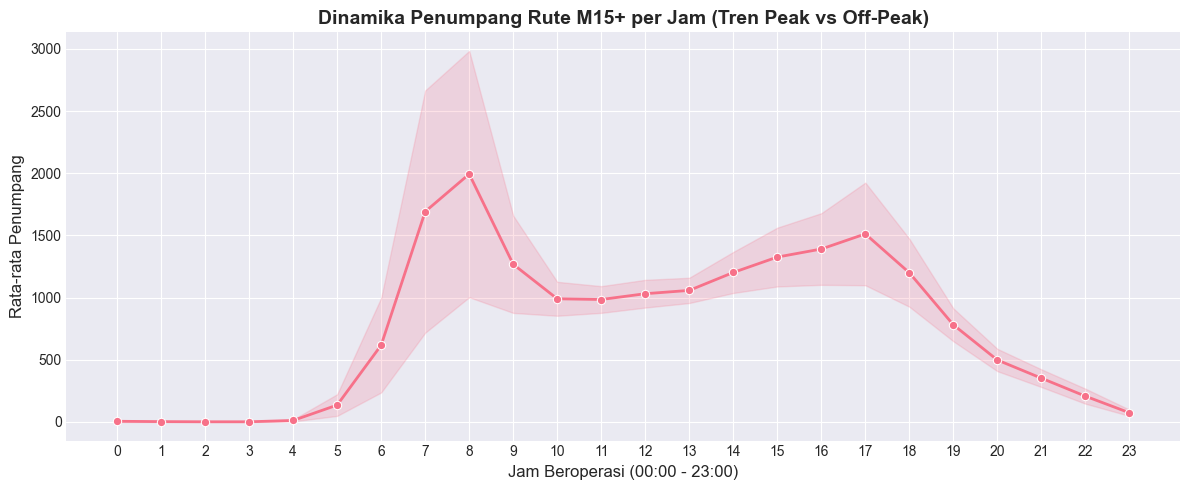

Batas Maksimal Historis M15+ : 3,028 penumpang pada 2023-11-15 08:00:00


In [4]:
df_m15 = df[df['bus_route'] == 'M15+'].copy()

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_m15, x='hour', y='total_ridership', estimator='mean', errorbar='sd', marker='o', linewidth=2)
plt.title('Dinamika Penumpang Rute M15+ per Jam (Tren Peak vs Off-Peak)', fontsize=14, fontweight='bold')
plt.xlabel('Jam Beroperasi (00:00 - 23:00)', fontsize=12)
plt.ylabel('Rata-rata Penumpang', fontsize=12)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

max_m15 = df_m15.loc[df_m15['total_ridership'].idxmax()]
print(f"Batas Maksimal Historis M15+ : {max_m15['total_ridership']:,} penumpang pada {max_m15['transit_timestamp']}")

## 2. Fenomena Zero-Inflation (Akar Masalah MAPE > 100%)

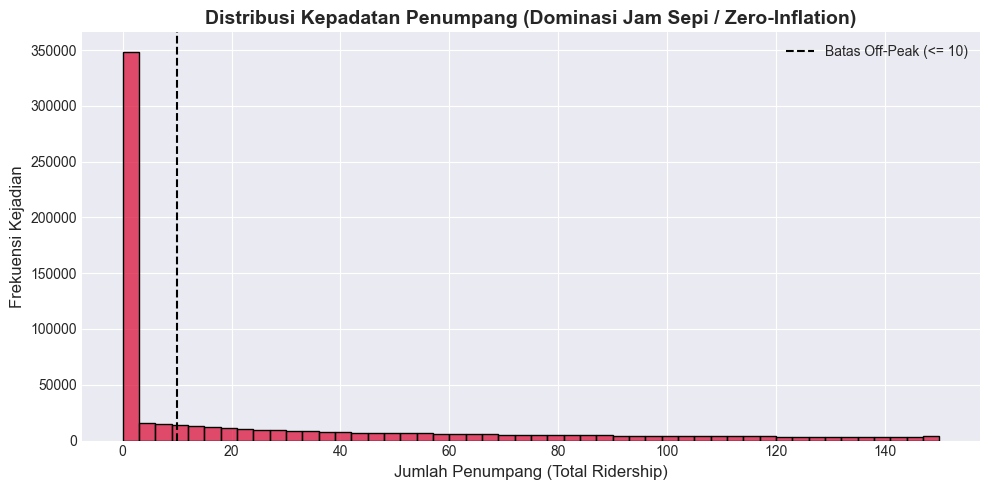

Porsi data operasional dengan penumpang sangat sepi (<= 10 orang): 45.43% dari seluruh sistem.


In [3]:
plt.figure(figsize=(10, 5))
# Memotong tampilan pada angka 150 agar penumpukan di angka 0-10 terlihat jelas
sns.histplot(df[df['total_ridership'] <= 150]['total_ridership'], bins=50, kde=False, color='crimson')
plt.title('Distribusi Kepadatan Penumpang (Dominasi Jam Sepi / Zero-Inflation)', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Penumpang (Total Ridership)', fontsize=12)
plt.ylabel('Frekuensi Kejadian', fontsize=12)

# Garis batas Off-Peak
plt.axvline(x=10, color='black', linestyle='--', label='Batas Off-Peak (<= 10)')
plt.legend()
plt.tight_layout()
plt.show()

pct_offpeak = (df[df['total_ridership'] <= 10].shape[0] / df.shape[0]) * 100
print(f"Porsi data operasional dengan penumpang sangat sepi (<= 10 orang): {pct_offpeak:.2f}% dari seluruh sistem.")